# Якість даних

`bigquery-public-data.google_analytics_sample`, серпень 2016 — серпень 2017
Числа рахуються запитами з `sql/00_data_quality.sql`, результати вивантажені в `data/`.

Перед аналізом треба знати, що в даних лежить насправді і де вони поводяться не так, як здається з назв полів. Кожна перевірка тут закінчується рішенням — від них залежать усі подальші розрахунки, і ухвалити їх треба до першого тесту, поки ще не видно, який варіант дає красивішу картинку. Рішення, що впливають на перевірку гіпотез, переносяться в `hypotheses.md`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATA = Path('data') if Path('data').exists() else Path('..') / 'data'
if not DATA.exists():
    raise FileNotFoundError(f'Не знайдено теку з даними: {DATA.resolve()}')
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

def load(name):
    return pd.read_csv(DATA / name)

def load_optional(name, columns=None):
    """Файли, вивантажені після першої версії блоку. Якщо файлу ще немає —
    ноутбук проходить до кінця й друкує, чого бракує"""
    path = DATA / name
    if not path.exists():
        print(f'[{name} не знайдено]')
        return None
    df = pd.read_csv(path)
    if columns and not set(columns).issubset(df.columns):
        print(f'[{name}: очікувалися колонки {list(columns)}, '
              f'а у файлі {list(df.columns)} — схоже, збережений інший запит]')
        return None
    return df

# Правило виключення внутрішнього трафіку Google — єдине джерело правди,
# використовується і в графіку, і в підрахунках нижче.
# Реферали з субдоменів *.google.com; `google.com` без субдомена під нього не підпадає.
def is_internal_google(source):
    return source.str.endswith('.google.com')

plt.rcParams.update({
    'figure.figsize': (9, 4.5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 10,
})

## Обсяг даних

In [2]:
dup = load('02_session_duplicates.csv')
ch  = load('01_unknown_channels.csv')

rows      = int(dup.rows_total[0])
sessions  = int(dup.distinct_sessions[0])
visitors  = int(dup.distinct_visitors[0])

print(f'Рядків у таблицях:        {rows:,}')
print(f'Унікальних сесій:         {sessions:,}')
print(f'Унікальних відвідувачів:  {visitors:,}')
print(f'Сесій на відвідувача:     {sessions / visitors:.2f}')

Рядків у таблицях:        903,653
Унікальних сесій:         902,755
Унікальних відвідувачів:  714,167
Сесій на відвідувача:     1.26


**Майже мільйон сесій за 12 місяців, покупок 1,3%. Обсягу вистачає на всі заплановані розрізи.**

Масштаб робочий: майже мільйон сесій за 12 місяців, покупок серед них близько 1,3%. Рішення взяти весь період, а не один місяць, було правильним. Далі дані доведеться ділити одночасно за каналом і за кроком воронки — це кілька десятків груп. За рік покупок 11,5 тисяч, за місяць було б близько тисячі, і в кожній групі лишилося б по кілька десятків спостережень: надто мало для будь-якого тесту.

Сесій на відвідувача — 1,27. Більшість людей приходить один раз і не повертається. Це знадобиться в кінці, коли йтиметься про гіпотезу 4.

## 1. Джерела трафіку

In [3]:
# Колонку pct_unknown_channel із CSV не показую: вона рахована від кількості рядків,
# а в ноутбуці всі відсотки — від унікальних сесій. Одне число замість двох.
display(ch.drop(columns=['pct_unknown_channel']))

pct_unknown = 100 * ch.unknown_channel[0] / sessions
pct_direct  = 100 * ch.source_direct[0]   / sessions

print(f'Без визначеного каналу: {ch.unknown_channel[0]:,} сесій ({pct_unknown:.3f}%)')
print(f'Direct:                 {ch.source_direct[0]:,} сесій ({pct_direct:.1f}%)')

,sessions,unknown_channel,medium_none_or_notset,source_direct
0,903653,120,371584,371469


Без визначеного каналу: 120 сесій (0.013%)
Direct:                 371,469 сесій (41.1%)


**Каналів вистачає: без визначеного каналу лише 0,013% сесій. Але 41% трафіку — direct, і це піднімає ставки в гіпотезі 4.**

Сесій без визначеного каналу виявилося 120, тобто 0,013%. Я очікувала, що доведеться виключати помітну частку даних, а виключати практично нічого — ці 120 сесій прибираю з міжканальних порівнянь, вони не змінять жодного числа.

Натомість спливло інше, чого я не шукала: direct — це 41% усього трафіку, найбільша група в датасеті. Залишаю його як повноцінний канал. Це валідна категорія: прямі заходи, збережені закладки і все, для чого браузер не передав реферер.

Але саме через розмір direct і є головним бенефіціаром атрибуції за останнім кліком. Людина, яка вперше прийшла з пошуку, а купила з закладки, віддає всю заслугу direct. Це те, що перевіряє гіпотеза 4, і тепер видно, що ставки там високі — йдеться про 41% трафіку, а не про маргінальну групу.

## 2. Чи справді один рядок = одна сесія

In [14]:
dup_keys = rows - sessions
print(f'Рядків:                    {rows:,}')
print(f'Унікальних ключів сесії:   {sessions:,}')
print(f'Різниця (дублі ключа):     {dup_keys:,} ({100 * dup_keys / rows:.3f}%)')

key = load_optional('08_session_key_check.csv', ['rows_total', 'key_2', 'key_3'])
if key is not None:
    k3 = int(key.key_3[0])
    print(f'Ключ з датою:              {k3:,}')
    print()
    print('Дата робить ключ унікальним' if k3 == rows
          else 'УВАГА: дата НЕ робить ключ унікальним — треба перевіряти далі')
else:
    print()
    print('Перевірка ключа з датою не виконана.')

Рядків:                    903,653
Унікальних ключів сесії:   902,755
Різниця (дублі ключа):     898 (0.099%)
Ключ з датою:              903,653

Дата робить ключ унікальним


**Ключ сесії не унікальний, причина технічна. Розводжу ключ рядка й ключ поведінкової сесії.**

Ключ `fullVisitorId + visitId` виявився не унікальним: 898 рядків мають дубль ключа, 0,099% даних. Причина технічна — `visitId` це час початку візиту в unix-форматі, і він повторюється, коли сесія перетинає межу доби й потрапляє у дві денні таблиці. Перевірила прямо: `COUNT(*)` = 903 653, ключ з двох полів = 902 755, ключ з датою = 903 653. Дата справді робить ключ унікальним, тобто діагноз підтверджений, а не припущений.

Але додавання дати має ціну, яку варто назвати. Сесія, що почалася до півночі, з таким ключем перетворюється на дві. Тому розводжу два поняття. `fullVisitorId + visitId + date` — ключ **рядка**, для контролю дублікатів і зведення сум. `fullVisitorId + visitId` — ключ **поведінкової сесії**, за яким збирається воронка, щоб перегляд товару до півночі й покупка після лишилися однією сесією, а не перетворилися на «покупку без перегляду». Саме так побудований запит `03_funnel_steps`.

Ці 0,1% не змінять жодного висновку. Фіксую їх, щоб `COUNT(*)` і `COUNT(DISTINCT ключ)` не розходилися в різних запитах — інакше через тиждень я не згадаю, яке з двох чисел правильне.

## 3. Послідовність воронки — головна знахідка блоку

In [5]:
fs = load('03_funnel_steps.csv')
display(fs)

p  = int(fs.purchase_sessions[0])
nv = int(fs.purchase_without_view[0])
nc = int(fs.purchase_without_cart[0])
nk = int(fs.purchase_without_checkout[0])

for label, n in [('без перегляду товару', nv), ('без додавання в кошик', nc), ('без checkout', nk)]:
    print(f'Покупок {label:<24} {n:>6,}  ({100 * n / p:5.2f}%)')

,purchase_sessions,purchase_without_view,purchase_without_cart,purchase_without_checkout,pct_purchase_without_view
0,11551,2163,1421,7,18.73


Покупок без перегляду товару      2,163  (18.73%)
Покупок без додавання в кошик     1,421  (12.30%)
Покупок без checkout                  7  ( 0.06%)


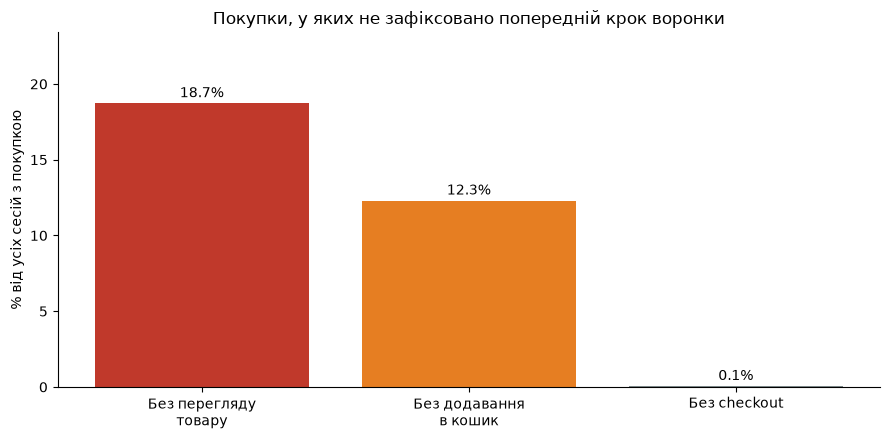

In [6]:
labels = ['Без перегляду\nтовару', 'Без додавання\nв кошик', 'Без checkout']
vals   = [100 * nv / p, 100 * nc / p, 100 * nk / p]

fig, ax = plt.subplots()
bars = ax.bar(labels, vals, color=['#c0392b', '#e67e22', '#7f8c8d'])
ax.set_ylabel('% від усіх сесій з покупкою')
ax.set_title('Покупки, у яких не зафіксовано попередній крок воронки')
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.4, f'{v:.1f}%', ha='center')
ax.set_ylim(0, max(vals) * 1.25)
plt.tight_layout()
plt.show()

**Воронка не послідовна: 18,7% покупок без зафіксованого перегляду товару. Роблю її монотонною, строгу версію лишаю як контроль.**

У 18,7% сесій з покупкою немає зафіксованого перегляду картки товару, у 12,3% — немає додавання в кошик. А без checkout — лише 7 покупок з 11 551, тобто 0,06%.

Цікавий тут радше розподіл пропусків, ніж їхній обсяг: низ воронки цілісний, верх — ні. Якби дані були биті випадково, пропуски розподілилися б рівномірно по кроках.

Тому будую воронку монотонною: якщо сесія досягла кроку k, вона зараховується як така, що пройшла всі попередні, незалежно від того, чи зафіксована відповідна подія. Строгу версію рахую теж, як контроль, і розбіжність виношу в README.

Причин дві. Перша: `action_type = '2'` фіксується не при кожному способі потрапити до товару — з кошика, зі списку побажань чи за прямим посиланням можна дійти до покупки, не згенерувавши цю подію. Друга: сесійна воронка обрізає поведінку між візитами, тому людина могла покласти товар у кошик учора, а купити сьогодні, і сьогоднішня сесія виглядатиме як покупка нізвідки. Якщо лишити строгу версію, конверсія кроку «перегляд — кошик» механічно завищиться: зі знаменника випадуть саме ті сесії, які пройшли крок непоміченими.

Це єдине рішення тут, яке впливає на сам результат перевірки: гіпотези 1 і 2 обидві про конверсії кроків. Тому воно записується в `hypotheses.md` до першого тесту: інакше на етапі аналізу спокуса вибрати ту версію воронки, яка дає зручнішу картинку, була б цілком реальною.

## 4. Дублікати transactionId

In [7]:
tx  = load('04_tx_duplicates.csv')
txe = load('04b_tx_duplicates_examples.csv')

display(tx)
display(txe.head(8))

,distinct_transaction_ids,ids_in_multiple_hits,ids_in_multiple_sessions
0,11552,11548,0


,tx_id,hit_rows,sessions_per_tx,revenue_sum_if_naive
0,ORD201703041515,50,1,"2,058.09"
1,ORD201703041514,42,1,"1,616.33"
2,ORD201705312661,30,1,480.00
3,ORD201703022050,24,1,"1,352.63"
4,ORD201703041891,20,1,"1,241.57"
5,ORD201703142587,16,1,936.71
6,ORD201612133278,16,1,162.31
7,ORD201610211869,16,1,502.79


**Це не дублікати, а перевипуск події покупки. Виручку й замовлення ніколи не сумувати по хітах.**

Формально «дублікатів» майже стільки ж, скільки транзакцій: 11 548 з 11 552 `transactionId` зустрічаються більш ніж в одному рядку. Але в кількох сесіях — рівно нуль.

Дивлюся на самі дублікати, щоб не пояснювати їх здогадкою — запит `10_tx_revenue_hits`. Картина інша, ніж я думала спершу. У транзакції `ORD201703041515` двадцять п'ять хітів з `action_type = '6'`, у кожного **своя** сума — 72.96, 99.95, 80.96 і так далі — і після кожного йде другий хіт з тим самим `transactionId` і `NULL` у виручці. Це не рядки товарів: товари в GA лежать у масиві `hits.product`, а не окремими хітами. Це подія покупки, яка перевипускається протягом сесії два десятки разів, з номерами хітів, розтягнутими по всій сесії — 37, 51, 70, 84.

Видаляти нічого не треба. Замість цього фіксую правило: виручку й кількість замовлень ніколи не сумувати по хітах. Транзакції рахуються як `COUNT(DISTINCT transactionId)`, виручка береться з рівня сесії.

`sessions_per_tx = 1` для всіх транзакцій означає, що жодне замовлення не розтеклося між сесіями — дані цілі. Небезпека тут у запиті, а не в даних. Розподіл із `10b` показує, наскільки вона підступна: у 11 165 транзакцій з 11 552 (96,6%) рівно один хіт несе суму, тобто наївний `SUM` дав би правильне число — саме тому помилку легко не помітити. Псує все хвіст із 350 транзакцій, де подія покупки перевипустилася: в `ORD201703041515` наївна сума дає 2 058 USD замість однієї покупки. Колонка `revenue_sum_if_naive` показує цю помилку, зафіксовану навмисно, щоб я впізнала її, якщо колись припущуся.

## 5. Виручка: розподіл і джерело правди

In [8]:
rev = load('05_revenue_distribution.csv')
display(rev.T.rename(columns={0: 'значення'}))

with_rev = int(rev.sessions[0] - rev.revenue_null[0])
tx_ids   = int(tx.distinct_transaction_ids[0])

print('Три близькі числа, які легко переплутати:')
print(f'  сесій з покупкою (крок 6, з №3):   {p:,}')
print(f'  унікальних transactionId (з №4):   {tx_ids:,}')
print(f'  сесій з ненульовою виручкою:       {with_rev:,}')
print(f'Покупок без записаної суми:          {p - with_rev:,}')
print()
print(f'p50 → p99:  ×{rev.p99_usd[0] / rev.p50_usd[0]:.1f}')
print(f'p99 → max:  ×{rev.max_usd[0] / rev.p99_usd[0]:.1f}')

,значення
sessions,"903,653.00"
revenue_null,"892,138.00"
revenue_zero,0.00
revenue_negative,0.00
min_usd,0.01
p50_usd,49.41
p95_usd,494.62
p99_usd,"1,272.45"
max_usd,"23,129.50"


Три близькі числа, які легко переплутати:
  сесій з покупкою (крок 6, з №3):   11,551
  унікальних transactionId (з №4):   11,552
  сесій з ненульовою виручкою:       11,515
Покупок без записаної суми:          36

p50 → p99:  ×25.8
p99 → max:  ×18.2


In [9]:
src = load('05b_revenue_source_of_truth.csv')
display(src)

gap = src.hit_level_usd[0] - src.session_level_usd[0]
print(f'Розбіжність: ${gap:,.2f} ({100 * gap / src.session_level_usd[0]:.1f}% від рівня сесії)')
print()

rh = load_optional('10b_rev_hits_distribution.csv', ['rev_hits', 'tx_count'])
if rh is not None:
    display(rh)
    tot   = int(rh.tx_count.sum())
    zero  = int(rh.loc[rh.rev_hits == 0, 'tx_count'].sum())
    one   = int(rh.loc[rh.rev_hits == 1, 'tx_count'].sum())
    multi = tot - zero - one

    print(f'Транзакцій усього:                {tot:,}')
    print(f'  рівно один хіт несе суму:       {one:,} ({100 * one / tot:.1f}%) — наївний SUM тут не помиляється')
    print(f'  подія перевипущена (2 і більше): {multi:,} ({100 * multi / tot:.1f}%) — саме звідси весь розрив')
    print(f'  жодного хіта з сумою:            {zero:,} — транзакція є, суми немає')
    print()
    if multi:
        print(f'Надлишок на одну перевипущену транзакцію: ${gap / multi:,.0f} у середньому')
    print(f'Звірка з перевіркою 5: {tot:,} − {zero} = {tot - zero:,} — рівно стільки сесій з ненульовою виручкою')
else:
    print('Розподіл хітів із сумою не показаний.')

,session_level_usd,hit_level_usd
0,"1,540,071.24","1,782,822.23"


Розбіжність: $242,750.99 (15.8% від рівня сесії)



,rev_hits,tx_count
0,0,37
1,1,11165
2,2,282
3,3,31
4,4,12
5,5,9
6,6,5
7,7,3
8,8,3
9,10,1


Транзакцій усього:                11,552
  рівно один хіт несе суму:       11,165 (96.6%) — наївний SUM тут не помиляється
  подія перевипущена (2 і більше): 350 (3.0%) — саме звідси весь розрив
  жодного хіта з сумою:            37 — транзакція є, суми немає

Надлишок на одну перевипущену транзакцію: $694 у середньому
Звірка з перевіркою 5: 11,552 − 37 = 11,515 — рівно стільки сесій з ненульовою виручкою


**Розрив у виручці 15,8% пояснений повністю: він сидить у 3% замовлень. Джерело правди — рівень сесії.**

Три речі.

Нулів і від'ємних значень немає взагалі, а 98,7% сесій мають `NULL`. Поле просто не заповнюється там, де покупки не було. Тому `NULL` не замінюю на нуль: така заміна знищила б різницю між «покупки не було» і «покупка була на нуль доларів», а другого в цих даних не трапляється жодного разу. Після неї `AVG(transactionRevenue)` дав би число, близьке до нуля, і воно виглядало б як осмислений середній чек. Отже, середній чек рахую тільки по сесіях з покупкою, а виручку на сесію — як суму виручки, поділену на всі сесії.

Розподіл сильно скошений: медіана 49 USD, 99-й перцентиль 1 272 USD, максимум 23 130 USD. Максимум у 18 разів більший за 99-й перцентиль: 1 272 USD відсікають 99% покупок, а найбільша сягає 23 130. Це підтверджує методичні рішення з пре-реєстрації: t-тест для середнього чека непридатний, а порівняння каналів через коефіцієнт варіації у гіпотезі 3 залишається коректним, бо CV безрозмірний і не потребує симетрії.

Дві суми виручки не збігаються: на рівні сесії 1 540 071 USD, на рівні хітів 1 782 822 USD, розрив 242 751 USD, тобто 15,8%. Розподіл `10b` пояснює його повністю. У 11 165 транзакцій (96,6%) суму несе рівно один хіт. У 350 транзакцій (3,0%) подія покупки перевипустилася — від двох разів до двадцяти п'яти, — і кожен повтор приносить власну суму. Ці 350 і дають увесь надлишок: у середньому близько 694 USD на транзакцію. Тобто розрив не розмазаний по даних, а зосереджений у трьох відсотках замовлень, і рахувати виручку по хітах означало б завищити її саме через них. За джерело правди беру рівень сесії: вся аналітика ведеться в гранулярності сесії, і брати виручку з іншого рівня означало б рахувати чисельник і знаменник на різних сітках. Вибір зроблений один раз і далі не міняється.

І несподіваний бонус: той самий розподіл закриває розбіжність, яку я лишила без пояснення в попередній версії. Сесій з покупкою 11 551, унікальних `transactionId` 11 552, сесій з ненульовою виручкою 11 515. У 37 транзакцій `rev_hits = 0` — жоден хіт не несе суми взагалі, і 11 552 − 37 дає рівно 11 515. Отже, «покупки без записаної суми» — не втрата при агрегації, а транзакції, де сума не записалася від початку. Залишаю їх у конверсії й виключаю із середнього чека, як і планувала, але тепер це спирається на механізм, а не на округлення.

## 6. Порожні pageviews

In [10]:
pv = load('06_null_pageviews.csv')
display(pv.drop(columns=['pct_pageviews_null']))

print(f'Без pageviews: {pv.pageviews_null[0]:,} сесій '
      f'({100 * pv.pageviews_null[0] / sessions:.3f}%), '
      f'з них з покупкою: {pv.null_pageviews_with_revenue[0]}')

,sessions,pageviews_null,hits_null,null_pageviews_with_revenue
0,903653,100,0,0


Без pageviews: 100 сесій (0.011%), з них з покупкою: 0


**Порожні pageviews не заважають: 0,011% сесій, жодної покупки серед них. Лишаю як є.**

100 сесій без `pageviews`, це 0,011%, і жодна з них не містить покупки. Залишаю як є.

Обсяг нижчий за будь-який поріг, що впливає на результат, і без покупок вони не діють на воронку взагалі. Виключати їх — зайва дія, яку довелося б описувати й пам'ятати.

## 7. Кандидати на виключення

In [11]:
ss = load('07_suspicious_sources.csv')
display(ss.head(12))

# Повний перебір субдоменів *.google.com — без сортування за конверсією й без LIMIT.
ig = load_optional('09_internal_google_full.csv', ['source', 'sessions', 'purchase_sessions'])
if ig is not None:
    display(ig.head(10))
else:
    print('Далі рахується лише те, що потрапило у зріз 07 — тобто неповний список.')

,source,medium,sessions,purchase_sessions,conversion_pct
0,dealspotr.com,referral,528,40,7.58
1,mail.google.com,referral,1457,62,4.26
2,groups.google.com,referral,1025,38,3.71
3,google,cpm,496,17,3.43
4,phandroid.com,referral,222,6,2.70
5,(direct),(none),371467,8742,2.35
6,dfa,cpm,5686,124,2.18
7,google,cpc,13078,243,1.86
8,l.facebook.com,referral,795,13,1.64
9,yahoo,organic,1478,22,1.49


,source,medium,sessions,purchase_sessions
0,analytics.google.com,referral,16172,0
1,sites.google.com,referral,2983,42
2,mail.google.com,referral,1457,62
3,groups.google.com,referral,1025,38
4,plus.google.com,referral,524,5
5,docs.google.com,referral,388,1
6,productforums.google.com,referral,364,0
7,optimize.google.com,referral,175,0
8,support.google.com,referral,101,0
9,hangouts.google.com,referral,83,0


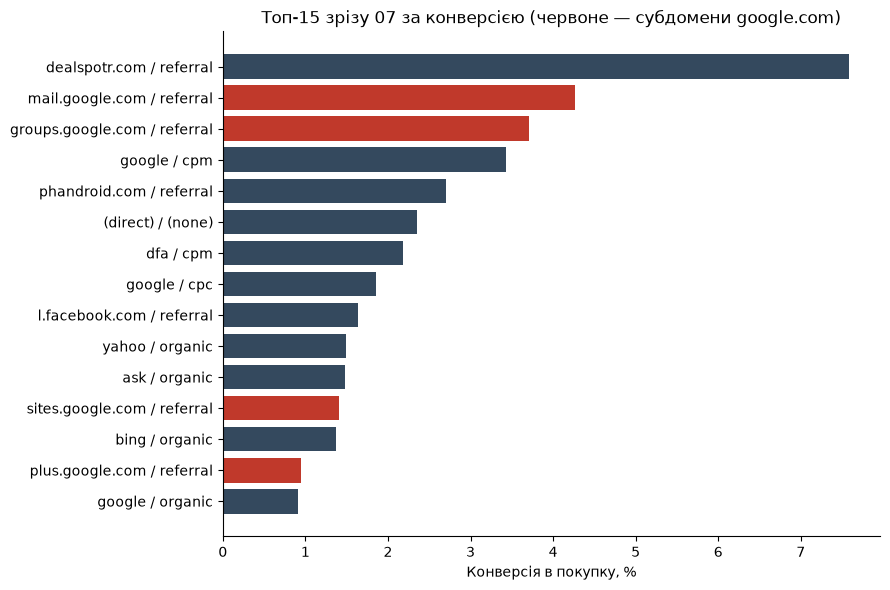

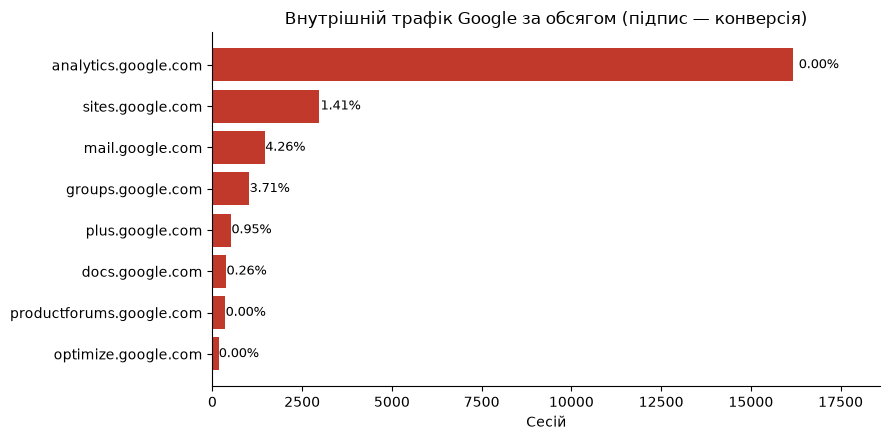

In [12]:
top = ss.head(15).sort_values('conversion_pct')
colors = ['#c0392b' if v else '#34495e' for v in is_internal_google(top.source)]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top.source + ' / ' + top.medium, top.conversion_pct, color=colors)
ax.set_xlabel('Конверсія в покупку, %')
ax.set_title('Топ-15 зрізу 07 за конверсією (червоне — субдомени google.com)')
plt.tight_layout()
plt.show()

# Той самий трафік, але відсортований за обсягом, а не за конверсією.
# Саме цей поворот показує джерело, якого не було на графіку вище.
if ig is not None:
    igt = ig.sort_values('sessions', ascending=False).head(8).sort_values('sessions')
    conv = 100 * igt.purchase_sessions / igt.sessions

    fig, ax = plt.subplots(figsize=(9, 4.5))
    bars = ax.barh(igt.source, igt.sessions, color='#c0392b')
    ax.set_xlabel('Сесій')
    ax.set_title('Внутрішній трафік Google за обсягом (підпис — конверсія)')
    for b, c in zip(bars, conv):
        ax.text(b.get_width() * 1.01, b.get_y() + b.get_height() / 2,
                f'{c:.2f}%', va='center', fontsize=9)
    ax.set_xlim(0, igt.sessions.max() * 1.15)
    plt.tight_layout()
    plt.show()

In [13]:
FIVE_HIGH_CONV = ['mail.google.com', 'groups.google.com', 'sites.google.com',
                  'plus.google.com', 'docs.google.com']

if ig is not None:
    s_all, p_all = int(ig.sessions.sum()), int(ig.purchase_sessions.sum())
    five = ig[ig.source.isin(FIVE_HIGH_CONV)]
    rest = ig[~ig.source.isin(FIVE_HIGH_CONV)]
    s_5, p_5 = int(five.sessions.sum()), int(five.purchase_sessions.sum())
    s_r, p_r = int(rest.sessions.sum()), int(rest.purchase_sessions.sum())

    print(f'Субдоменів *.google.com: {len(ig)}')
    print(f'Разом:            {s_all:,} сесій ({100 * s_all / sessions:.2f}% усіх), '
          f'{p_all:,} покупок, конверсія {100 * p_all / s_all:.2f}%')
    print(f'  з них 5 «видимих» у зрізі 07: {s_5:,} сесій, конверсія {100 * p_5 / s_5:.2f}%')
    print(f'  решта {len(rest)} джерел:      {s_r:,} сесій, конверсія {100 * p_r / s_r:.2f}%')
    print()

    biggest = ig.sort_values('sessions', ascending=False).iloc[0]
    print(f'Найбільше внутрішнє джерело: {biggest.source} — '
          f'{int(biggest.sessions):,} сесій, {int(biggest.purchase_sessions)} покупок')
    print('У зрізі 07 його немає: сортування йшло за конверсією, а вона тут нульова.')
else:
    int_rows = ss[is_internal_google(ss.source)]
    display(int_rows)
    print(f'Внутрішній трафік (лише те, що видно у зрізі 07): '
          f'{int_rows.sessions.sum():,} сесій — це НЕПОВНЕ число')

print()
yt = ss[ss.source == 'youtube.com']
if len(yt):
    print(f'youtube.com: {int(yt.sessions.iloc[0]):,} сесій '
          f'({100 * int(yt.sessions.iloc[0]) / sessions:.1f}% усього трафіку), '
          f'{int(yt.purchase_sessions.iloc[0])} покупок, '
          f'конверсія {yt.conversion_pct.iloc[0]}%')
else:
    print('youtube.com не потрапив у зріз 07_suspicious_sources.csv')

Субдоменів *.google.com: 28
Разом:            23,506 сесій (2.60% усіх), 152 покупок, конверсія 0.65%
  з них 5 «видимих» у зрізі 07: 6,377 сесій, конверсія 2.32%
  решта 23 джерел:      17,129 сесій, конверсія 0.02%

Найбільше внутрішнє джерело: analytics.google.com — 16,172 сесій, 0 покупок
У зрізі 07 його немає: сортування йшло за конверсією, а вона тут нульова.

youtube.com: 212,602 сесій (23.6% усього трафіку), 11 покупок, конверсія 0.01%


**Внутрішнього трафіку Google утричі більше, ніж показав перший зріз, — мій же запит його ховав. Виключаю всі субдомени *.google.com.**

Внутрішній трафік Google присутній, і його виявилося втричі більше, ніж показав перший зріз. Запит `07` відсортований за конверсією й обрізаний на тридцяти рядках — тому в нього не потрапило найбільше внутрішнє джерело з усіх, `analytics.google.com`: 16 172 сесії й **нуль покупок**. Воно було невидиме саме тому, що конвертує в нуль, а сортування йшло від найвищої конверсії. Повний перебір субдоменів (`09_internal_google_full`) дає 28 джерел і 23 506 сесій — 2,6% трафіку замість 0,7%, які я порахувала спершу.

Група всередині неоднорідна. `mail`, `groups`, `sites`, `plus`, `docs` разом дають 6 377 сесій із конверсією 2,32% — у 2–5 разів вище за середні 1,28%. Решта 23 джерела — 17 129 сесій і 4 покупки, тобто 0,02%. Це переважно робочі інтерфейси Google: `analytics`, `adwords`, `optimize`, `datastudio`, `keep`, `inbox`, `hangouts`, `takeout`.

Виключаю всі реферали з субдоменів `*.google.com`. Правило просте й відтворюване, на відміну від списку, зібраного руками. Визнаю його межу: `sites.google.com` хостить сторонні сайти, а `groups` і `plus` — публічні майданчики, тому частина виключеного може бути й зовнішньою аудиторією. Тому конверсію Referral показую у двох варіантах, з ними і без них. Окремо зазначу, що `google.com` без субдомена (4 669 сесій) під правило не підпадає й лишається: це зовнішній реферал, а не внутрішній інтерфейс.

Важливо, куди це правило б'є. Спершу здавалося, що виключення прибирає високу конверсію й робить Referral скромнішим. Насправді найбільше воно прибирає 16 тисяч сесій, які не купили жодного разу, тобто діє в протилежний бік і Referral **підіймає**. Критерій — нерепрезентативність аудиторії, а не саме по собі високе число — застосований чесно, ріже в обидва боки.

Найвища конверсія в списку взагалі в іншого джерела — `dealspotr.com`, 7,58%. Це купонний агрегатор, і висока конверсія там очікувана: люди приходять з готовим наміром купити зі знижкою. Залишаю. Співробітники, які заходять із внутрішнього інтерфейсу, — це не покупці магазину мерчу в тому ж сенсі, що зовнішні відвідувачі, тож їхня конверсія не є властивістю каналу Referral. Купонний сайт — звичайний зовнішній канал, і його виключення було б підгонкою даних під очікування.

І окремо — знахідка, якої я не шукала: `youtube.com` дає 212 602 сесії, майже чверть усього трафіку, і 11 покупок. Конверсія 0,01%. Залишаю обов'язково.

Мінімальний розмір комірки — 100 сесій. Цей поріг стоїть у запиті `07` всередині `sql/00_data_quality.sql`, і після перегляду даних я його підтверджую: на рівні каналів він ні на що не впливає, бо в `channelGrouping` вісім груп і найменша з них на порядки більша. Діяти він почне на дрібних розрізах — канал × пристрій × крок воронки — і саме там потрібен.

## Рішення за підсумками перевірки

| # | Рішення | Впливає на гіпотези |
|---|---|---|
| 1 | Виключені джерела: всі реферали з субдоменів `*.google.com` (28 джерел, 23 506 сесій, 2,6%). Referral показується у двох варіантах | 1, 3, 4 |
| 2 | Мінімальний розмір комірки — 100 сесій | 1, 2 |
| 3a | Ключ **рядка** — `fullVisitorId + visitId + date`; перевірено, збігається з `COUNT(*)` | усі |
| 3b | Ключ **поведінкової сесії** для воронки — `fullVisitorId + visitId`, щоб не різати сесії через північ | 1, 2 |
| 4 | Воронка монотонна; строга версія рахується як контроль | **1, 2** |
| 5 | Джерело правди для виручки — рівень сесії | 3 |
| 6 | `NULL` у виручці не замінюється нулем; середній чек — тільки по сесіях з покупкою | 3 |
| 7 | Транзакції рахуються як `COUNT(DISTINCT transactionId)`, ніколи не сумуванням по хітах | 3 |
| 8 | `direct`, `youtube.com`, `dealspotr.com`, `google.com` без субдомена залишаються в аналізі | 1, 4 |

У `hypotheses.md` переносяться рішення №1, 2, 3b, 4, 5 і 6 — ті, що впливають на перевірку гіпотез. Решта стосується техніки виконання й лишається тут.

Рішення №4 — єдине, що змінює сам результат перевірки. Тому воно фіксується до першого тесту.

## Що перевірка даних уже сказала про гіпотези

Три речі, які варто прочитати до аналізу. Жодна не є результатом перевірки й жодна не змінює формулювань.

**Ставки у гіпотезі 4 вищі, ніж я думала.** Direct — 41% трафіку, тобто найбільший бенефіціар атрибуції за останнім кліком — це найбільша група в датасеті, а не маргінальний канал. Водночас сесій на відвідувача лише 1,27: більшість людей приходить один раз, і для них first-touch збігається з last-click. Ці два факти тягнуть у різні боки, і наперед незрозуміло, який переважить.

**У гіпотезі 1 з'явилися конкуренти серед пояснень, і їх двоє.** Перший — `youtube.com`, чверть трафіку з конверсією 0,01%. Другий — 23 тисячі сесій внутрішнього Google, які осідають у Referral. Обидва означають одне: якщо розкид між каналами вгорі воронки виявиться великим, перша підозра має падати на склад груп, а не на самі канали. Тому перед тестуванням гіпотези 1 треба подивитися склад груп `channelGrouping` за джерелами — інакше висновок буде про youtube, а не про канали.

**Гіпотеза 3 методично підтверджена.** Розподіл чеків скошений настільки, що максимум у 18 разів більший за 99-й перцентиль. Відмова від t-тесту на користь коефіцієнтів варіації була правильною.

**Що лишилося невиміряним і йде в обмеження.** Монотонна воронка дозаписує пропущені кроки лише тим сесіям, які дійшли далі. Сесія, яка подивилась товар нестандартним шляхом і пішла, лишається як «не дивилась» — тобто крок 1 виміряний точніше для покупців, ніж для непокупців. Якщо частота таких шляхів різниться по каналах, це саме по собі створює міжканальний розкид угорі воронки. Цифру беру першим запитом при побудові воронки: частка сесій із хітами, але без жодного `action_type = '2'`, у розрізі каналів.